# Проект: Многоцелевая модель для NER + event-CLS

Этот Jupyter-ноутбук - пошаговый шаблон для выполнения проекта по объединённой (multi-task) модели, решающей **NER (BIO, token-level)** и **CLS (document-level multihot событий/отношений)** на датасете NEREL.

Внимание: вам нужно реализовать весь рабочий код - в ноутбуке предустановлены только парсеры строкового формата. Все остальные ячейки служат как инструкции / места для вашего кода.


#### Структура ноутбука 

1. Подготовка окружения (пути, seed, imports)
2. EDA - загрузка jsonl, обзор, графики, выводы 
3. Парсинг и таргеты - здесь уже есть парсеры строкового формата NEREL; нужно реализовать сбор примеров (`build_examples_from_nerel`) 
4. Токенизация, выравнивание меток, DataLoader - реализовать `tokenize_and_align_labels`, Dataset/Collator 
5. Модель (JointModel) и кастомный loss (uncertainty-weighting) - реализовать модельный класс и loss
6. Тренировка/валидация - training loop, оптимизатор, scheduler, логирование метрик
7. Инференс и анализ ошибок - реализовать inference pipeline и примеры



In [1]:
import json
from random import seed
from typing import List
import re
import random
from collections import Counter

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from transformers import DataCollatorForTokenClassification
import torch.nn.functional as F


/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed(42)
plt.style.use('seaborn-v0_8-bright')
pd.set_option('display.max_columns', 512)

##### 1. EDA

Цели:

- Прочитать первые 50–200 записей `train.jsonl` (путь `/data/train.jsonl`).
- Посчитать частоты: entity types, relation/event types.
- Построить графики: топ-15 entity types, распределение длины текстов, число сущностей на документ.
- Написать 2–3 коротких вывода в Markdown: что можно ожидать при моделировании (редкие типы, длинные документы и т. п.).




In [3]:
data_path = 'nerel/'

with open(data_path + 'train.jsonl', 'r') as json_file:
    json_list = list(json_file)
    train_data = [json.loads(elem) for elem in json_list]
with open(data_path + 'test.jsonl', 'r') as json_file:
    json_list = list(json_file)
    test_data = [json.loads(elem) for elem in json_list]
with open(data_path + 'dev.jsonl', 'r') as json_file:
    json_list = list(json_file)
    dev_data = [json.loads(elem) for elem in json_list]

with open(data_path + 'rel_types.jsonl', 'r') as json_file:
    json_list = list(json_file)
    rel_types_data = [json.loads(elem) for elem in json_list]
with open(data_path + 'ent_types.jsonl', 'r') as json_file:
    json_list = list(json_file)
    ent_types_data = [json.loads(elem) for elem in json_list]

In [4]:
rel_types_dict = {elem['type']: 0 for elem in rel_types_data}
ent_types_dict = {elem['type']: 0 for elem in ent_types_data}

In [5]:
print(ent_types_dict)

{'AGE': 0, 'AWARD': 0, 'CITY': 0, 'COUNTRY': 0, 'CRIME': 0, 'DATE': 0, 'DISEASE': 0, 'DISTRICT': 0, 'EVENT': 0, 'FACILITY': 0, 'FAMILY': 0, 'IDEOLOGY': 0, 'LANGUAGE': 0, 'LAW': 0, 'LOCATION': 0, 'MONEY': 0, 'NATIONALITY': 0, 'NUMBER': 0, 'ORDINAL': 0, 'ORGANIZATION': 0, 'PENALTY': 0, 'PERCENT': 0, 'PERSON': 0, 'PRODUCT': 0, 'PROFESSION': 0, 'RELIGION': 0, 'STATE_OR_PROVINCE': 0, 'TIME': 0, 'WORK_OF_ART': 0}


In [6]:
print(rel_types_dict)

{'ABBREVIATION': 0, 'KNOWS': 0, 'AGE_IS': 0, 'AGE_DIED_AT': 0, 'ALTERNATIVE_NAME': 0, 'AWARDED_WITH': 0, 'PLACE_OF_BIRTH': 0, 'CAUSE_OF_DEATH': 0, 'DATE_DEFUNCT_IN': 0, 'DATE_FOUNDED_IN': 0, 'DATE_OF_BIRTH': 0, 'DATE_OF_CREATION': 0, 'DATE_OF_DEATH': 0, 'POINT_IN_TIME': 0, 'PLACE_OF_DEATH': 0, 'FOUNDED_BY': 0, 'HEADQUARTERED_IN': 0, 'IDEOLOGY_OF': 0, 'LOCATED_IN': 0, 'SPOUSE': 0, 'MEDICAL_CONDITION': 0, 'MEMBER_OF': 0, 'ORGANIZES': 0, 'ORIGINS_FROM': 0, 'OWNER_OF': 0, 'PARENT_OF': 0, 'PLACE_RESIDES_IN': 0, 'PRICE_OF': 0, 'PRODUCES': 0, 'RELATIVE': 0, 'RELIGION_OF': 0, 'SCHOOLS_ATTENDED': 0, 'SIBLING': 0, 'SUBEVENT_OF': 0, 'SUBORDINATE_OF': 0, 'TAKES_PLACE_IN': 0, 'WORKPLACE': 0, 'WORKS_AS': 0, 'START_TIME': 0, 'END_TIME': 0, 'CONVICTED_OF': 0, 'PENALIZED_AS': 0, 'PART_OF': 0, 'HAS_CAUSE': 0, 'AGENT': 0, 'PARTICIPANT_IN': 0, 'INANIMATE_INVOLVED': 0, 'EXPENDITURE': 0, 'INCOME': 0}


In [7]:
train_data[0].keys()

dict_keys(['id', 'text', 'entities', 'relations', 'links'])

In [8]:
text = train_data[0]['text']
entities = train_data[0]['entities']
relations = train_data[0]['relations']
links = train_data[0]['links']

In [9]:
print(text[:100])

Пулеметы, автоматы и снайперские винтовки изъяты в арендуемом американцами доме в Бишкеке

05/08/200


In [10]:
entities[:5]

['T1\tNATIONALITY 62 74\tамериканцами',
 'T2\tCITY 82 89\tБишкеке',
 'T3\tDATE 117 126\t5 августа',
 'T4\tCOUNTRY 136 142\tГрузия',
 'T5\tORGANIZATION 145 179\tПравоохранительные органы Киргизии']

In [11]:
entities[5-1], entities[70-1]

('T5\tORGANIZATION 145 179\tПравоохранительные органы Киргизии',
 'T70\tEVENT 410 417\tАрсенал')

In [12]:
relations[:10]

['R1\tTAKES_PLACE_IN Arg1:T70 Arg2:T12',
 'R2\tAGE_IS Arg1:T101 Arg2:T13',
 'R3\tHEADQUARTERED_IN Arg1:T72 Arg2:T4',
 'R4\tHEADQUARTERED_IN Arg1:T5 Arg2:T6',
 'R5\tHEADQUARTERED_IN Arg1:T42 Arg2:T73',
 'R6\tORGANIZES Arg1:T5 Arg2:T70',
 'R7\tLOCATED_IN Arg1:T12 Arg2:T8',
 'R8\tLOCATED_IN Arg1:T8 Arg2:T6',
 'R9\tOWNER_OF Arg1:T101 Arg2:T12',
 'R10\tSUBEVENT_OF Arg1:T106 Arg2:T70']

In [13]:
ent_counts, rel_counts, char_counts = [], [], []
for elem in train_data:
    text = elem['text']
    entities = elem['entities']
    relations = elem['relations']
    links = elem['links']
    ent_counts.append(len(entities))
    rel_counts.append(len(relations))
    char_counts.append(len(text))

    for ent in entities:
        ent_types_dict[ent.split('\t')[1].split()[0]] += 1
    for rel in relations:
        rel_types_dict[rel.split('\t')[1].split()[0]] += 1

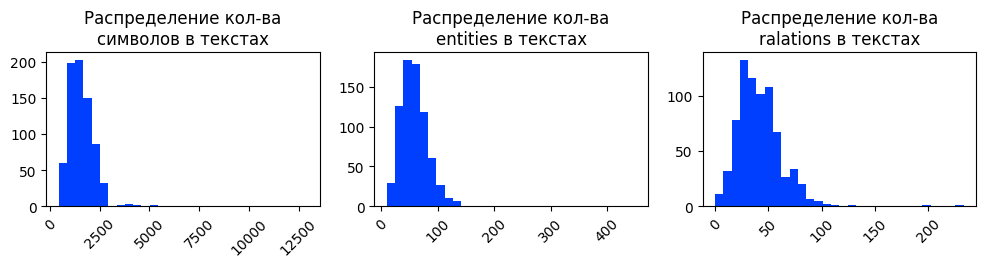

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(12, 2))
for i, cnt, title_suffix in zip(range(3), 
             [char_counts, ent_counts, rel_counts], 
             ['символов', 'entities', 'ralations']):
    ax[i].hist(cnt, bins=30)
    ax[i].set_title(f'Распределение кол-ва\n{title_suffix} в текстах')
    ax[i].tick_params(axis='x', labelrotation=45)

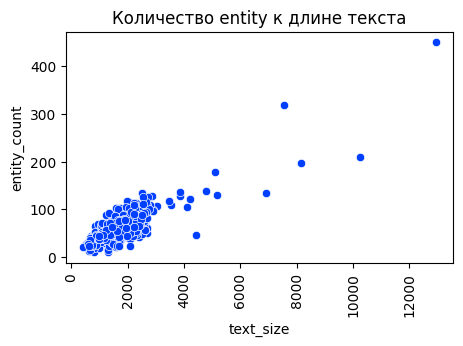

In [15]:
df = pd.DataFrame({'text_size': char_counts, 'entity_count': ent_counts})
plt.figure(figsize=(5, 3))
fig = sns.scatterplot(x=df['text_size'], y=df['entity_count'])
fig.tick_params(axis='x', rotation=90)
plt.title('Количество entity к длине текста');

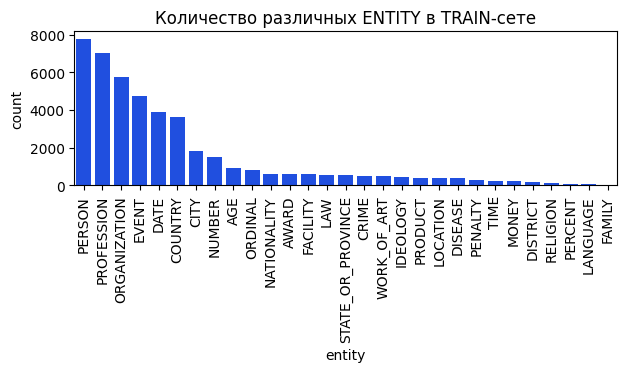

In [16]:
df = pd.DataFrame(list(ent_types_dict.items()), columns = ['entity', 'count'])
df = df.sort_values('count', ascending=False).reset_index(drop=True)
plt.figure(figsize=(7, 2))
fig = sns.barplot(x=df['entity'], y=df['count'])
fig.tick_params(axis='x', rotation=90)
plt.title('Количество различных ENTITY в TRAIN-сете');

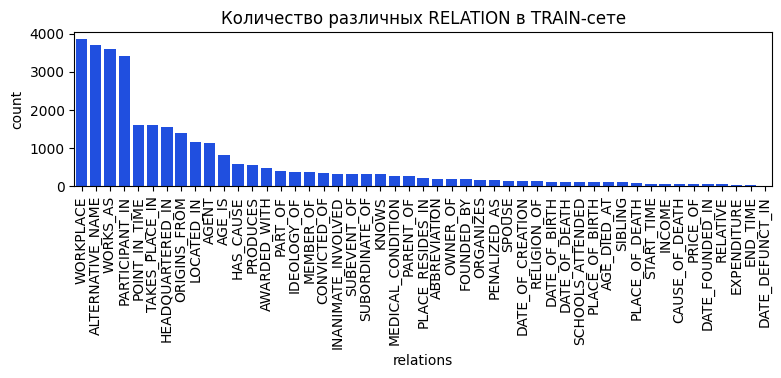

In [17]:
df = pd.DataFrame(list(rel_types_dict.items()), columns = ['relations', 'count'])
df = df.sort_values('count', ascending=False).reset_index(drop=True)
plt.figure(figsize=(9, 2))
fig = sns.barplot(x=df['relations'], y=df['count'])
fig.tick_params(axis='x', rotation=90)
plt.title('Количество различных RELATION в TRAIN-сете');

In [18]:
EVENT_LIST = list(rel_types_dict.keys())

In [19]:
EVENT_LIST

['ABBREVIATION',
 'KNOWS',
 'AGE_IS',
 'AGE_DIED_AT',
 'ALTERNATIVE_NAME',
 'AWARDED_WITH',
 'PLACE_OF_BIRTH',
 'CAUSE_OF_DEATH',
 'DATE_DEFUNCT_IN',
 'DATE_FOUNDED_IN',
 'DATE_OF_BIRTH',
 'DATE_OF_CREATION',
 'DATE_OF_DEATH',
 'POINT_IN_TIME',
 'PLACE_OF_DEATH',
 'FOUNDED_BY',
 'HEADQUARTERED_IN',
 'IDEOLOGY_OF',
 'LOCATED_IN',
 'SPOUSE',
 'MEDICAL_CONDITION',
 'MEMBER_OF',
 'ORGANIZES',
 'ORIGINS_FROM',
 'OWNER_OF',
 'PARENT_OF',
 'PLACE_RESIDES_IN',
 'PRICE_OF',
 'PRODUCES',
 'RELATIVE',
 'RELIGION_OF',
 'SCHOOLS_ATTENDED',
 'SIBLING',
 'SUBEVENT_OF',
 'SUBORDINATE_OF',
 'TAKES_PLACE_IN',
 'WORKPLACE',
 'WORKS_AS',
 'START_TIME',
 'END_TIME',
 'CONVICTED_OF',
 'PENALIZED_AS',
 'PART_OF',
 'HAS_CAUSE',
 'AGENT',
 'PARTICIPANT_IN',
 'INANIMATE_INVOLVED',
 'EXPENDITURE',
 'INCOME']

##### Парсинг и подготовка таргетов

Ниже - две заранее подготовленные функции парсинга строкового формата NEREL. Их вы получаете и можете использовать сразу (не меняйте имена).

Ожидаемые дополнительные функции, которые вы должны реализовать:

- `build_examples_from_nerel(records: List[dict], event_list: List[str]) -> List[dict]` - для каждого документа вернуть словарь с полями: `text`, `tokens` (word-tokenization по пробелам), `token_spans` (символьные оффсеты слов), `tags` (BIO per token), `cls_vec` (multihot длиной len(event_list)).

- `make_event_list(records, K=30)` - собрать топ-K типов событий/relations и вернуть список.



**Правила BIO и сопоставления:**

- Токенизация для BIO - простая `text.split()` (по пробелам). Офсеты токенов вычисляются на основе поиска токена в тексте (учтите повторы; используйте скользящий указатель).
- Для каждой сущности (start, end - символьные оффсеты) пометьте токены, которые пересекаются с интервалом сущности.
- Метки: `B-TYPE`, `I-TYPE`, `O`.



In [20]:


# Функции парсинга строкового формата NEREL
def parse_entity_line(line: str):
    parts = line.split('\t')
    if len(parts) < 3:
        return None
    ent_id = parts[0].strip()
    type_pos = parts[1].strip()
    text = parts[2].strip() if len(parts) > 2 else ''
    m = re.match(r'(\S+)\s+(\d+)\s+(\d+)', type_pos)
    if not m:
        return None
    ent_type = m.group(1)
    start = int(m.group(2))
    end = int(m.group(3))
    return {'id': ent_id, 'type': ent_type, 'start': start, 'end': end, 'text': text}

def parse_relation_line(line: str):
    parts = line.split('\t')
    if len(parts) < 2:
        return None
    rel_id = parts[0].strip()
    body = parts[1].strip()
    m = re.match(r'(\S+)\s+Arg1:(\S+)\s+Arg2:(\S+)', body)
    if not m:
        return None
    rel_type = m.group(1)
    arg1 = m.group(2); arg2 = m.group(3)
    return {'id': rel_id, 'type': rel_type, 'arg1': arg1, 'arg2': arg2}

In [21]:
def whitespace_tokenize_with_offsets(text: str):
    tokens = []
    spans = []
    for m in re.finditer(r'\S+', text):
        tokens.append(m.group())
        spans.append((m.start(), m.end()))
    return tokens, spans 

In [22]:
def make_event_list(records, K=30):
    relations_dict = {}

    for rec in records:
        relations = list(set([parse_relation_line(line)['type'] for line in rec['relations']]))

        for rel in relations:
            if rel in relations_dict:
                relations_dict[rel] += 1
            else:
                relations_dict[rel] = 1
    data = list(relations_dict.items())
    data = sorted(data, key=lambda x: x[1], reverse=True)

    return [d[0] for d in data[:K]]

In [23]:
def build_examples_from_nerel(records: List[dict], event_list: List[str]) -> List[dict]:

    mlb = MultiLabelBinarizer()
    mlb.fit([event_list])

    examples = []
    
    for rec in records:
        tokens, token_spans = whitespace_tokenize_with_offsets(rec['text'])
        token_labels = ["O"] * len(tokens)

        # Пройдите по rec.objects и заполните token_labels
        # Ваш код здесь
        for line in rec['entities']:
            obj = parse_entity_line(line)
            base_type = obj['type']
            span_start = obj['start']
            span_end = obj['end']


            overlapping_idxs = []
            for i, (t_start, t_end) in enumerate(token_spans):
                if not (t_end <= span_start or t_start >= span_end):
                    overlapping_idxs.append(i)
            if not overlapping_idxs:
                # можно логировать: print(f"No overlap for span {span_start}-{span_end} in doc {rec.id}")
                continue
            for j, tok_idx in enumerate(overlapping_idxs):
                if token_labels[tok_idx] != "O":
                    continue
                prefix = "B" if j == 0 else "I"
                token_labels[tok_idx] = f"{prefix}-{base_type}"


        relations = set([parse_relation_line(line)['type'] for line in rec['relations']])
        cls_vec = mlb.transform([relations])[0]

        examples.append({
            "text": rec['text'],
            "tokens": tokens,
            "tags": token_labels,
            "cls_vec": cls_vec,
        })

    return examples

In [24]:
EVENT_LIST = make_event_list(train_data, K=30)
len(EVENT_LIST)

30

In [25]:
train_examples = build_examples_from_nerel(train_data, EVENT_LIST)
test_examples = build_examples_from_nerel(test_data, EVENT_LIST)
dev_examples = build_examples_from_nerel(dev_data, EVENT_LIST)

/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['PLACE_OF_BIRTH', 'SCHOOLS_ATTENDED'] will be ignored
  warnings.warn(
/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['PENALIZED_AS'] will be ignored
  warnings.warn(
/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['DATE_OF_CREATION', 'PENALIZED_AS'] will be ignored
  warnings.warn(
/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['PLACE_OF_BIRTH'] will be ignored
  warnings.warn(
/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unkn

In [26]:
train_examples[0].keys()

dict_keys(['text', 'tokens', 'tags', 'cls_vec'])

In [27]:
train_examples[0]['tags'][:5]

['O', 'O', 'O', 'O', 'O']

In [28]:
train_examples[0]['cls_vec']

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0])

In [29]:
# for examples in [train_examples, test_examples]:
#     for ex in examples:
#         ex["tags"] = [label2id[t] for t in ex["tags"]]

In [30]:
# dataset = DatasetDict({"train": train_examples, "test": test_examples})

##### 3. Токенизация и выравнивание меток

Задачи:

- Выбрать `AutoTokenizer(..., use_fast=True)`.
- Реализовать `tokenize_and_align_labels(examples, tokenizer, label2id, max_length)`:
  - Токенизировать текст (return_offsets_mapping
  - Преобразовать word-level BIO метки в token-level метки (subword → label = -100 / ignore_index, для первых субтокенов ставится соответствующий тег `B-`/`I-`)
  - Вернуть словарь с `input_ids`, `attention_mask`, `labels` (token-level), `cls_labels`

- Собрать `torch.utils.data.Dataset` и `DataLoader`. Можно использовать `DataCollatorForTokenClassification` либо сделать кастомный collator, который возвращает батчи с `cls_labels`.



In [31]:
unique_labels = set()
for ex in train_examples+test_examples:
    unique_labels.update(ex["tags"])
unique_labels.add("O")
label_list = sorted(unique_labels)
label2id = {lab: i for i, lab in enumerate(label_list)}
id2label = {i: lab for lab, i in label2id.items()}

In [32]:
len(unique_labels)

57

In [33]:
MODEL_NAME = "cointegrated/rubert-tiny2"
# attention_model = AutoModel.from_pretrained(model_name, output_attentions=True) # Ваш код здесь
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # Ваш код здесь

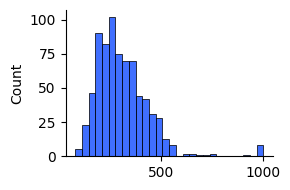

In [34]:
# Для подбора max_length
tokenized = tokenizer(
    [e['tokens'] for e in train_examples],
    is_split_into_words=True,
    truncation=True,
    padding="max_length",
    max_length=1000,
)
tkn_lengths = [sum([el == 1 for el in atm])  for atm in  tokenized['attention_mask']]
sns.displot(tkn_lengths, height=2, aspect=1.5);

In [35]:
MAX_LENGTH = 512

In [36]:
train_examples[0].keys()

dict_keys(['text', 'tokens', 'tags', 'cls_vec'])

In [37]:
tokenized = tokenizer(
    [e['tokens'] for e in train_examples[:2]],
    is_split_into_words=True,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH,
)

In [38]:
def tokenize_and_align_labels(examples, tokenizer, label2id, max_length):

    tokenized = tokenizer(
        [e['tokens'] for e in examples],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_length,
    )
    labels = []
    cls_labels = []

    for i, exam in enumerate(examples):
        cls_labels.append(exam['cls_vec'].tolist())
        word_labels = [label2id[t] for t in exam['tags']]

        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word_idx = None
        for word_idx in word_ids:
            # Условие: если word_idx == None, то это padding/special token
            # Иначе, если word_idx != prev_word_idx, то это начало нового слова
            # Ваш код здесь
            if word_idx is None:
                label_ids.append(-100)  # .append(-100)
            elif word_idx != prev_word_idx:
                label_ids.append(word_labels[word_idx])
            else:
                label_ids.append(-100)  # .append(-100)
            prev_word_idx = word_idx
        labels.append(label_ids)
    
    return {
        'input_ids': tokenized['input_ids'],
        'attention_mask': tokenized['attention_mask'], 
        'labels': labels, 
        'cls_labels': cls_labels
    }

In [39]:
train_tokenized = tokenize_and_align_labels(train_examples, tokenizer, label2id, max_length=MAX_LENGTH)
test_tokenized = tokenize_and_align_labels(test_examples, tokenizer, label2id, max_length=MAX_LENGTH)

In [40]:
train_examples[0].keys()

dict_keys(['text', 'tokens', 'tags', 'cls_vec'])

In [41]:
train_tokenized.keys()

dict_keys(['input_ids', 'attention_mask', 'labels', 'cls_labels'])

In [42]:
train_examples[0]['tags']

['O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'B-NATIONALITY',
 'O',
 'O',
 'B-CITY',
 'B-DATE',
 'I-TIME',
 'B-CITY',
 'B-DATE',
 'I-DATE',
 'B-COUNTRY',
 'B-ORGANIZATION',
 'I-ORGANIZATION',
 'I-ORGANIZATION',
 'O',
 'O',
 'O',
 'O',
 'B-NATIONALITY',
 'B-COUNTRY',
 'O',
 'B-CITY',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'B-DATE',
 'I-DATE',
 'B-ORGANIZATION',
 'B-ORGANIZATION',
 'I-ORGANIZATION',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'B-EVENT',
 'O',
 'O',
 'B-CITY',
 'O',
 'O',
 'O',
 'B-AGE',
 'B-NATIONALITY',
 'B-COUNTRY',
 'O',
 'O',
 'B-NATIONALITY',
 'B-COUNTRY',
 'B-EVENT',
 'I-EVENT',
 'I-EVENT',
 'B-NUMBER',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'B-NUMBER',
 'O',
 'O',
 'B-NUMBER',
 'I-NUMBER',
 'B-NUMBER',
 'O',
 'O',
 'B-PRODUCT',
 'B-NUMBER',
 'I-NUMBER',
 'B-NUMBER',
 'O',
 'O',
 'O',
 'O',
 'B-NUMBER',
 'O',
 'O',
 'B-NUMBER',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'B-NUMBER',
 'O',
 'O',
 'B-NUMBER',
 'I-NUMBER',
 'O',
 'B-PRODUCT

In [43]:
train_tokenized['labels'][0]

[-100,
 56,
 -100,
 -100,
 -100,
 56,
 56,
 56,
 -100,
 56,
 56,
 56,
 56,
 -100,
 16,
 56,
 56,
 2,
 -100,
 5,
 -100,
 -100,
 -100,
 -100,
 54,
 -100,
 -100,
 2,
 -100,
 -100,
 -100,
 -100,
 -100,
 5,
 34,
 3,
 -100,
 -100,
 -100,
 -100,
 -100,
 19,
 -100,
 47,
 47,
 56,
 56,
 56,
 -100,
 56,
 -100,
 16,
 3,
 56,
 2,
 -100,
 -100,
 56,
 -100,
 -100,
 56,
 56,
 56,
 -100,
 56,
 -100,
 56,
 5,
 34,
 19,
 -100,
 -100,
 19,
 47,
 -100,
 56,
 -100,
 56,
 56,
 56,
 -100,
 -100,
 -100,
 56,
 56,
 56,
 -100,
 56,
 8,
 -100,
 -100,
 56,
 56,
 -100,
 2,
 -100,
 -100,
 -100,
 56,
 56,
 -100,
 56,
 -100,
 0,
 -100,
 -100,
 16,
 3,
 56,
 56,
 -100,
 16,
 3,
 -100,
 8,
 37,
 37,
 -100,
 17,
 56,
 -100,
 56,
 56,
 56,
 -100,
 56,
 -100,
 56,
 56,
 56,
 56,
 56,
 -100,
 17,
 56,
 56,
 17,
 -100,
 -100,
 45,
 -100,
 -100,
 17,
 56,
 -100,
 -100,
 56,
 23,
 -100,
 -100,
 -100,
 -100,
 17,
 -100,
 -100,
 45,
 -100,
 17,
 56,
 56,
 56,
 -100,
 56,
 -100,
 17,
 56,
 -100,
 -100,
 56,
 -100,
 -100,
 17,
 5

In [44]:
class CustomDictionaryDataset(Dataset):
    """
    A custom PyTorch Dataset class to load data from a dictionary.
    The dictionary is expected to have the same number of items for each key.
    """
    def __init__(self, data_dict):
        # super().__init__()
        self.data_dict = data_dict
        # Assuming all lists in the dictionary have the same length
        self.length = len(next(iter(data_dict.values())))

    def __len__(self):
        # Return the total number of samples in the dataset
        return self.length

    def __getitem__(self, idx):
        # Return a single sample as a dictionary at the given index
        sample = {key: torch.tensor(self.data_dict[key][idx]) for key in self.data_dict}
        return sample

In [45]:
type(train_tokenized)

dict

In [46]:
train_dataset = CustomDictionaryDataset(train_tokenized)
test_dataset = CustomDictionaryDataset(test_tokenized)

In [47]:
len(label2id)

57

In [48]:
data_collator = DataCollatorForTokenClassification(tokenizer)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=data_collator
)

test_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=data_collator
)

In [49]:
for batch in test_dataloader:
    break

##### 4. Модель: `JointModel` + custom loss (uncertainty weighting)


In [50]:
import torch.nn as nn
import timm

In [130]:
class Config:
    SEED = 42

    TEXT_MODEL_NAME = MODEL_NAME
    # IMAGE_MODEL_NAME = "tf_efficientnet_b0"

    # TEXT_MODEL_UNFREEZE = "encoder.layer.11|pooler"
    # IMAGE_MODEL_UNFREEZE = "blocks.6|conv_head|bn2"

    BATCH_SIZE = 16 #256
    
    TEXT_LR = 1e-3
    NER_LR = 1e-3
    MULTIHOT_LR = 1e-3
    LOSS_LR = 1e-3

    EPOCHS = 5 #30
    DROPOUT = 0.2
    HIDDEN_DIM = 256
    MAX_LENGTH = MAX_LENGTH

    NER_LABELS_COUNT = len(label2id)

    MULTIHOT_SIZE = len(EVENT_LIST)

    TEXT_MODEL_UNFREEZE = "encoder.layer.2.output|pooler"

    SAVE_PATH = "models/best_model.pth"


In [131]:
class JointModel(nn.Module):
    def __init__(self, config,):
        super().__init__()
        self.text_model = AutoModel.from_pretrained(config.TEXT_MODEL_NAME)

        self.ner_layer = nn.Sequential(
            nn.Linear(
                in_features=(
                    self.text_model.config.hidden_size
                ),
                out_features=config.HIDDEN_DIM,
                bias=True
            ),
            nn.LayerNorm(config.HIDDEN_DIM),
            nn.Hardswish(),
            nn.Dropout(p=config.DROPOUT),
            nn.Linear(in_features=config.HIDDEN_DIM,
                        out_features=config.NER_LABELS_COUNT, bias=True),
            nn.Softmax(dim=1)
        )

        self.multihot_layer = nn.Sequential(
            nn.Linear(
                in_features=(
                    self.text_model.config.hidden_size
                ),
                out_features=config.HIDDEN_DIM,
                bias=True
            ),
            nn.LayerNorm(config.HIDDEN_DIM),
            nn.Hardswish(),
            nn.Dropout(p=config.DROPOUT),
            nn.Linear(in_features=config.HIDDEN_DIM,
                        out_features=config.MULTIHOT_SIZE, bias=True),
            nn.Softmax(dim=1)
        )

    def forward(self, input_ids, attention_mask):
        text_model_output = self.text_model(
            input_ids=input_ids.contiguous(),            
            attention_mask=attention_mask.contiguous(),
        )
        
        token_features = text_model_output.last_hidden_state
        cls_features = text_model_output.last_hidden_state[:, -1, :]  # pooler_output 
        
        ner_output = self.ner_layer(token_features)


        # multihot_output = self.multihot_layer(text_model_output.pooler_output)
        multihot_output = self.multihot_layer(cls_features)

        return ner_output, multihot_output

In [132]:
class KendallLossWeighting(nn.Module):
    """
    Implements the uncertainty-based loss weighting from Kendall et al. 2018
    for multi-task learning.
    """
    def __init__(self, num_tasks):
        super(KendallLossWeighting, self).__init__()
        # Initialize log(sigma^2) for each task as a learnable parameter
        # using zeros as a starting point.
        self.log_sigma_sq = nn.Parameter(torch.zeros(num_tasks))

    def forward(self, losses):
        """
        Calculates the weighted loss sum.

        Args:
            losses (list of Tensors): List of individual task losses.
        
        Returns:
            Tensor: The combined, uncertainty-weighted loss.
        """
        assert len(losses) == len(self.log_sigma_sq), "Number of losses must match number of tasks"

        total_loss = 0
        for i, loss in enumerate(losses):
            # Formula from the paper: L_weighted = (1 / (2 * sigma_i^2)) * L_i + log(sigma_i)
            # We work with log_sigma_sq for numerical stability.
            
            # GOOGLE AI
            # # precision = 1 / (2 * sigma_i^2) = (1/2) * exp(-log_sigma_sq)
            # precision = 0.5 * torch.exp(-self.log_sigma_sq[i])
            # # log(sigma_i) = 0.5 * log(sigma_i^2) = 0.5 * log_sigma_sq
            # log_sigma = 0.5 * self.log_sigma_sq[i]  

            # PRACTICUM
            precision = torch.exp(-2.0 * self.log_sigma_sq[i])
            log_sigma = self.log_sigma_sq[i]

            total_loss += precision * loss + log_sigma
            
        return total_loss

In [133]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [134]:
device

device(type='cuda')

In [135]:
config = Config()
model = JointModel(config)
model.to(device)

loss_ner = nn.CrossEntropyLoss(ignore_index=-100)
loss_cls = nn.BCEWithLogitsLoss()

num_tasks = 2
loss_weighter = KendallLossWeighting(num_tasks)

In [136]:
for param, _ in model.named_parameters():
    print(param)

text_model.embeddings.word_embeddings.weight
text_model.embeddings.position_embeddings.weight
text_model.embeddings.token_type_embeddings.weight
text_model.embeddings.LayerNorm.weight
text_model.embeddings.LayerNorm.bias
text_model.encoder.layer.0.attention.self.query.weight
text_model.encoder.layer.0.attention.self.query.bias
text_model.encoder.layer.0.attention.self.key.weight
text_model.encoder.layer.0.attention.self.key.bias
text_model.encoder.layer.0.attention.self.value.weight
text_model.encoder.layer.0.attention.self.value.bias
text_model.encoder.layer.0.attention.output.dense.weight
text_model.encoder.layer.0.attention.output.dense.bias
text_model.encoder.layer.0.attention.output.LayerNorm.weight
text_model.encoder.layer.0.attention.output.LayerNorm.bias
text_model.encoder.layer.0.intermediate.dense.weight
text_model.encoder.layer.0.intermediate.dense.bias
text_model.encoder.layer.0.output.dense.weight
text_model.encoder.layer.0.output.dense.bias
text_model.encoder.layer.0.outp

In [137]:
def set_requires_grad(module, unfreeze_pattern="", verbose=False):
    if len(unfreeze_pattern) == 0:
        for param, _ in module.named_parameters():
            param.requires_grad = False
        return

    pattern = re.compile(unfreeze_pattern)

    for name, param in module.named_parameters():
        if pattern.search(name):
            param.requires_grad = True
            if verbose:
                print(f"Разморожен слой: {name}")
        else:
            param.requires_grad = False

In [138]:
# for i, (name, param) in enumerate(model.text_model.named_parameters()):
#     print(i, name, param.shape)

In [139]:
set_requires_grad(model,
                  unfreeze_pattern="encoder.layer.2|ner_layer|multihot_layer",
                  # unfreeze_pattern="ner_layer|multihot_layer",
                  verbose=True)

Разморожен слой: text_model.encoder.layer.2.attention.self.query.weight
Разморожен слой: text_model.encoder.layer.2.attention.self.query.bias
Разморожен слой: text_model.encoder.layer.2.attention.self.key.weight
Разморожен слой: text_model.encoder.layer.2.attention.self.key.bias
Разморожен слой: text_model.encoder.layer.2.attention.self.value.weight
Разморожен слой: text_model.encoder.layer.2.attention.self.value.bias
Разморожен слой: text_model.encoder.layer.2.attention.output.dense.weight
Разморожен слой: text_model.encoder.layer.2.attention.output.dense.bias
Разморожен слой: text_model.encoder.layer.2.attention.output.LayerNorm.weight
Разморожен слой: text_model.encoder.layer.2.attention.output.LayerNorm.bias
Разморожен слой: text_model.encoder.layer.2.intermediate.dense.weight
Разморожен слой: text_model.encoder.layer.2.intermediate.dense.bias
Разморожен слой: text_model.encoder.layer.2.output.dense.weight
Разморожен слой: text_model.encoder.layer.2.output.dense.bias
Разморожен сло

In [140]:
optimizer = torch.optim.Adam([
    {'params': model.text_model.parameters(), 'lr': config.TEXT_LR},
    {'params': model.ner_layer.parameters(), 'lr': config.NER_LR},
    {'params': model.multihot_layer.parameters(), 'lr': config.MULTIHOT_LR},
    {'params': loss_weighter.parameters(), 'weight_decay': 0, 'lr': config.LOSS_LR} # Often no weight decay on sigma
])

##### 5. Training / Validation



In [143]:
# Функция, выравнивающая предсказания модели и реальные метки (на уровне tokenized_dataset)
def get_flat_labels_and_preds_from_model(tokenized_split, model, device, max_samples=None, treshold_cls=0.5):
    """
    tokenized_split: dataset split (list-like of examples with keys 'input_ids','attention_mask','labels')
    Возвращает flat lists: y_true (ints), y_pred (ints)
    """
    y_true = []
    y_pred = []

    y_true_cls = []
    y_pred_cls = []
    for i, ex in enumerate(tokenized_split):
        if max_samples is not None and i >= max_samples:
            break

        input_ids = ex["input_ids"].unsqueeze(0).to(torch.long).to(device)
        attention_mask = ex["attention_mask"].unsqueeze(0).to(torch.long).to(device)

        with torch.no_grad():
            # outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            # logits = outputs.logits  # shape (1, seq_len, num_labels)
            logits, multihot = model(input_ids, attention_mask)

            preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().tolist()  # list длины seq_len

            preds_cls = (multihot.squeeze(0) > treshold_cls).int()

        # Истинные метки (включая -100 для пэддинга/ignored)
        true_labels = ex["labels"]  # список длиной seq_len; элементы -100 или id
        true_labels_cls = ex["cls_labels"]

        # Фильтруем позиции, где true != -100
        filtered_true = []
        filtered_pred = []
        for p, t in zip(preds, true_labels):
            if t == -100:
                continue
            filtered_true.append(int(t))
            filtered_pred.append(int(p))

        # Обрежем на минимальную длину (на случай рассинхронизации)
        minlen = min(len(filtered_true), len(filtered_pred))
        if minlen == 0:
            continue
        y_true.extend(filtered_true[:minlen])
        y_pred.extend(filtered_pred[:minlen])

        y_true_cls.extend(preds_cls.tolist())
        y_pred_cls.extend(true_labels_cls.tolist())


    return y_true, y_pred, y_true_cls, y_pred_cls

In [144]:
def validate(model, val_loader, device, loss_weighter): 
    model.eval()
    n_batches = 0
    total_loss = 0
    total_loss_ner = 0
    total_loss_cls = 0
    loss_ner = nn.CrossEntropyLoss(ignore_index=-100)
    loss_cls = nn.BCEWithLogitsLoss()
    with torch.no_grad():
        for batch in tqdm(val_loader):

            batch = {k: v.to(device) for k, v in batch.items()}
            ner_output, multihot_output = model(batch['input_ids'],                                            
                                                batch['attention_mask'],)           
            loss_ner_value = loss_ner(ner_output.view(-1, config.NER_LABELS_COUNT), batch['labels'].view(-1))
            loss_cls_value = loss_cls(multihot_output, batch['cls_labels'].float())

            total_weighted_loss = loss_weighter(losses=[loss_ner_value, loss_cls_value])
            total_loss += total_weighted_loss.item()
            total_loss_ner += loss_ner_value
            total_loss_cls += loss_cls_value
            n_batches += 1
        
        avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
        avg_loss_ner = total_loss_ner / n_batches if n_batches > 0 else 0.0
        avg_loss_cls = total_loss_cls / n_batches if n_batches > 0 else 0.0

    return avg_loss, avg_loss_ner.item(), avg_loss_cls.item() 

In [145]:
# 3) Loop обучения
val_loss, val_loss_ner, val_loss_cls = validate(model, test_dataloader, device, loss_weighter)
print(f"INIT VALIDATION: avg weighted loss: {val_loss:.4f} / avg loss_ner: {val_loss_ner:.4f} / val_loss_cls: {val_loss_cls:.4f}\n")

data = []
for epoch in range(config.EPOCHS):
    model.train()
    total_loss = 0.0
    n_batches = 0

    total_loss_ner = 0
    total_loss_cls = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}"):
    # for batch in train_dataloader:    
        optimizer.zero_grad()

        batch = {k: v.to(device) for k, v in batch.items()}
        ner_output, multihot_output = model(batch['input_ids'],                                            
                                            batch['attention_mask'],)
        
        loss_ner_value = loss_ner(ner_output.view(-1, config.NER_LABELS_COUNT), batch['labels'].view(-1))
        loss_cls_value = loss_cls(multihot_output, batch['cls_labels'].float())


        total_weighted_loss = loss_weighter(losses=[loss_ner_value, loss_cls_value])
        total_weighted_loss.backward()
        optimizer.step()

        total_loss += total_weighted_loss.item()
        total_loss_ner += loss_ner_value
        total_loss_cls += loss_cls_value
        n_batches += 1

    train_loss = total_loss / n_batches if n_batches > 0 else 0.0
    train_loss_ner = (total_loss_ner / n_batches).item() if n_batches > 0 else 0.0
    train_loss_cls = (total_loss_cls / n_batches).item() if n_batches > 0 else 0.0

    

    # Valiation
    val_loss, val_loss_ner, val_loss_cls  = validate(model, test_dataloader, device, loss_weighter)

    y_true_ner_val, y_pred_ner_val, y_true_cls_val, y_pred_cls_val = get_flat_labels_and_preds_from_model(
        test_dataset, 
        model, 
        device, 
        max_samples=None
    )
    f1_ner_macro = f1_score(y_true_ner_val, y_pred_ner_val, average='macro')
    f1_cls_micro = f1_score(y_true_cls_val, y_pred_cls_val, average='micro')

    accuracy_cls = accuracy_score(y_true_cls_val, y_pred_cls_val) 
    precision_cls = precision_score(y_true_cls_val, y_pred_cls_val) 
    recall_cls = recall_score(y_true_cls_val, y_pred_cls_val) 


    print(f"TRAIN: avg weighted loss {train_loss:.4f} / avg loss_ner {train_loss_ner:.4f} / avg_loss_cls {train_loss_cls:.4f}\n"
          f"VALID: avg weighted loss {val_loss:.4f} / avg loss_ner {val_loss_ner:.4f} / val_loss_cls {val_loss_cls:.4f} / "
          f" f1_ner_macro {f1_ner_macro:.4f} / f1_cls_micro {f1_cls_micro:.4f} / accuracy_cls {accuracy_cls:.4f} / "
          f"precision_cls {precision_cls:.4f} / recall_cls {recall_cls:.4f}")
    data.append({'epoch': epoch, 
                 'train_loss': train_loss,
                 'train_loss_ner': train_loss_ner,
                 'train_loss_cls': train_loss_cls,
                 'val_loss': val_loss,
                 'val_loss_ner': val_loss_ner,
                 'val_loss_cls': val_loss_cls,
                 'val_f1_ner_macro': f1_ner_macro,
                 'val_f1_cls_micro': f1_cls_micro,
                 'accuracy_cls': accuracy_cls,
                 'precision_cls': precision_cls,
                 'recall_cls': recall_cls,
                 })


100%|██████████| 47/47 [00:02<00:00, 16.95it/s]


INIT VALIDATION: avg weighted loss: 4.7396 / avg loss_ner: 4.0430 / val_loss_cls: 0.6966



100%|██████████| 47/47 [00:02<00:00, 17.96it/s]


TRAIN: avg weighted loss 4.5456 / avg loss_ner 4.0257 / avg_loss_cls 0.6822
VALID: avg weighted loss 4.3662 / avg loss_ner 4.0077 / val_loss_cls 0.6805 /  f1_ner_macro 0.1443 / f1_cls_micro 0.6190 / accuracy_cls 0.6190 / precision_cls 0.0760 / recall_cls 0.9355


100%|██████████| 47/47 [00:06<00:00,  7.58it/s]
/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

TRAIN: avg weighted loss 3.9657 / avg loss_ner 3.9912 / avg_loss_cls 0.6803
VALID: avg weighted loss 3.8474 / avg loss_ner 3.9854 / val_loss_cls 0.6804 /  f1_ner_macro 0.1849 / f1_cls_micro 0.6190 / accuracy_cls 0.6190 / precision_cls 0.0760 / recall_cls 0.9355


100%|██████████| 47/47 [00:02<00:00, 17.88it/s]


TRAIN: avg weighted loss 3.7502 / avg loss_ner 3.9870 / avg_loss_cls 0.6802
VALID: avg weighted loss 3.6487 / avg loss_ner 3.9817 / val_loss_cls 0.6799 /  f1_ner_macro 0.1767 / f1_cls_micro 0.6086 / accuracy_cls 0.6086 / precision_cls 0.0498 / recall_cls 0.9194


100%|██████████| 47/47 [00:02<00:00, 17.89it/s]


TRAIN: avg weighted loss 3.5652 / avg loss_ner 3.9831 / avg_loss_cls 0.6799
VALID: avg weighted loss 3.4776 / avg loss_ner 3.9778 / val_loss_cls 0.6798 /  f1_ner_macro 0.1915 / f1_cls_micro 0.6047 / accuracy_cls 0.6047 / precision_cls 0.0393 / recall_cls 0.9184


In [146]:
df = pd.DataFrame(data)

In [147]:
df

,epoch,train_loss,train_loss_ner,train_loss_cls,val_loss,val_loss_ner,val_loss_cls,val_f1_ner_macro,val_f1_cls_micro,accuracy_cls,precision_cls,recall_cls
0,0,4.545553,4.025740,0.682219,4.366243,4.007681,0.680511,0.144296,0.618996,0.618996,0.076049,0.935484
1,1,4.222928,4.000223,0.680351,4.080737,3.990986,0.680484,0.174949,0.589964,0.589964,0.000000,0.000000
2,2,3.965672,3.991181,0.680317,3.847380,3.985394,0.680354,0.184919,0.618996,0.618996,0.076049,0.935484
3,3,3.750214,3.986984,0.680182,3.648749,3.981657,0.679926,0.176664,0.608602,0.608602,0.049825,0.919355
4,4,3.565221,3.983078,0.679940,3.477578,3.977849,0.679799,0.191490,0.604659,0.604659,0.039336,0.918367


In [148]:
# torch.save(model.state_dict(), config.SAVE_PATH)

In [149]:
y_true, y_pred, y_true_cls, y_pred_cls = get_flat_labels_and_preds_from_model(test_dataset, model, device, max_samples=None)

In [150]:
len([n for k, n in id2label.items() if k in y_true])

56

In [151]:
try:
    print(classification_report(y_true, y_pred, target_names=[n for k, n in id2label.items() if k in y_true]))
except ValueError:
    print(classification_report(y_true, y_pred, target_names=[n for k, n in id2label.items()]))

                     precision    recall  f1-score   support

              B-AGE       0.58      0.81      0.67       138
            B-AWARD       0.09      0.33      0.14        94
             B-CITY       0.46      0.50      0.48       210
          B-COUNTRY       0.50      0.51      0.51       332
            B-CRIME       0.00      0.00      0.00        30
             B-DATE       0.83      0.71      0.77       479
          B-DISEASE       0.00      0.00      0.00        49
         B-DISTRICT       0.00      0.00      0.00        20
            B-EVENT       0.48      0.37      0.42       600
         B-FACILITY       0.09      0.48      0.16        60
           B-FAMILY       0.00      0.00      0.00        11
         B-IDEOLOGY       0.00      0.00      0.00        22
         B-LANGUAGE       0.00      0.00      0.00         8
              B-LAW       0.03      0.12      0.05        34
         B-LOCATION       0.00      0.00      0.00        38
            B-MONEY    

/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/russele7/practicum/dle/practicum_dle_sprint_5/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control

##### 6. Инференс, квантизация и анализ ошибок

Проведите качественный анализ на 8–10 примерах: где NER ошибается? Какие типы сущностей плохо определяются? Насколько квантизация может ускорить инференс и сильно ли она ухудшает модель?


## 6.1 Инференс

In [152]:
def inference(text, model, tokenizer, device, id2label,):
    
    tokens, _ = whitespace_tokenize_with_offsets(text)

    model.to(device)
    tokenized = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

    tokens_decoded = tokenizer.convert_ids_to_tokens(tokenized['input_ids'],)

    ner_output, cls_probabilities = model(input_ids=torch.tensor([tokenized['input_ids']], dtype=torch.long).to(device), 
                                        attention_mask=torch.tensor([tokenized['attention_mask']], dtype=torch.long).to(device))
    
    
    
    bio_labels = [id2label[i] for i in torch.argmax(ner_output.view(-1, config.NER_LABELS_COUNT), dim=-1).cpu().tolist()]

    return tokens_decoded, bio_labels, cls_probabilities

In [153]:
example = random.sample(test_examples, k=1)[0]

cls_treshold = 0.5
text = example['text']
tokens_true = example['tokens']
bio_true = example['tags']
cls_true = example['cls_vec']

tokens, bio_pred, cls_probabilities = inference(text, model, tokenizer, device, id2label,)
cls_pred = (cls_probabilities[0] > treshold_cls).int().cpu().detach().numpy()
filter_mask = [(t not in ['[CLS]', '[SEP]', '[PAD]']) for t in tokens]

tokens_filtered = [t for t, fm in zip(tokens, filter_mask) if fm]
bio_pred_filtered = [bp for bp, fm in zip(bio_pred, filter_mask) if fm]

In [154]:
df_ner = pd.DataFrame({'tokens': tokens_filtered, 'bio_pred': bio_pred_filtered,}).T
df_ner

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180
tokens,В,России,хотят,пони,##зить,градус,водки,до,37,",",5,Во,##дка,В,России,предложили,законодательно,снизить,минимальный,градус,водки,до,37,",",5,процента,.,Поправки,вступят,в,силу,с,1,июля,2018,года,.,Это,делается,",",чтобы,снять,противоречие,между,законом,и,ГОСТ,.,В,законе,«,О,гос,##регули,##ровании,производства,и,оборота,эти,##лового,спирта,[UNK],»,сказано,",",что,вод,##ка,[UNK],это,напиток,",",который,произведен,на,основе,эти,##лового,спирта,с,крепостью,38,[UNK],56,%,.,Благодаря,снижению,крепости,на,уровне,закона,в,России,может,появиться,«,новая,»,вод,##ка,.,У,нее,будет,необычный,вкус,",",считает,глава,Центра,исследований,федерального,и,регионального,рынков,Вадим,Дро,##би,##з,:,Он,добавил,",",что,себестоимость,напитка,также,изменится,за,счёт,меньшего,содержания,спирта,",",а,значит,",",и,более,низкого,налогового,сбора,.,Крепость,водки,зависит,от,региона,",",в,котором,живут,потребители,",",отмечают,эксперты,.,Например,",",потребители,из,Москвы,предпочитают,водку,в,40,%,",",более,«,холодные,»,территории,стараются,производить,более,горяч,##ительный,напиток,.
bio_pred,B-NUMBER,B-COUNTRY,O,I-PENALTY,I-CRIME,B-NUMBER,I-AWARD,I-FACILITY,B-AGE,I-STATE_OR_PROVINCE,B-NUMBER,I-NUMBER,I-AGE,B-NUMBER,B-COUNTRY,B-EVENT,I-CRIME,B-EVENT,B-AWARD,I-NUMBER,I-AWARD,I-FACILITY,B-MONEY,I-STATE_OR_PROVINCE,I-STATE_OR_PROVINCE,I-MONEY,I-PENALTY,B-EVENT,B-EVENT,I-AWARD,I-EVENT,B-DATE,I-TIME,I-DATE,I-DATE,I-DATE,I-CRIME,O,O,I-CRIME,O,B-NUMBER,I-CRIME,I-CRIME,I-CRIME,B-NUMBER,B-AWARD,I-NATIONALITY,I-CRIME,I-LAW,B-FACILITY,I-WORK_OF_ART,I-LAW,I-STATE_OR_PROVINCE,I-STATE_OR_PROVINCE,I-CRIME,B-NATIONALITY,I-LAW,I-CRIME,B-NATIONALITY,I-LAW,I-WORK_OF_ART,B-IDEOLOGY,B-NUMBER,B-IDEOLOGY,O,I-FACILITY,I-STATE_OR_PROVINCE,B-NUMBER,O,B-EVENT,I-PERCENT,O,O,I-CRIME,B-EVENT,I-CRIME,I-MONEY,I-FACILITY,I-FACILITY,I-TIME,B-AGE,I-CRIME,B-AGE,I-AGE,I-PERCENT,O,B-EVENT,I-TIME,I-CRIME,I-CRIME,I-LAW,I-CRIME,B-COUNTRY,O,O,B-NUMBER,I-FACILITY,I-STATE_OR_PROVINCE,I-FACILITY,I-STATE_OR_PROVINCE,I-PERCENT,O,O,O,B-NUMBER,B-NATIONALITY,B-RELIGION,O,B-PROFESSION,I-PROFESSION,I-ORGANIZATION,I-ORGANIZATION,I-STATE_OR_PROVINCE,I-ORGANIZATION,I-PROFESSION,B-PERSON,I-PERSON,I-FACILITY,I-STATE_OR_PROVINCE,B-ORDINAL,O,O,I-PERCENT,O,I-CRIME,B-NUMBER,O,O,B-NUMBER,I-CRIME,B-NUMBER,B-NUMBER,B-NATIONALITY,I-PERCENT,O,O,B-IDEOLOGY,O,B-NUMBER,I-NUMBER,B-NATIONALITY,B-NUMBER,I-TIME,B-ORGANIZATION,B-ORGANIZATION,B-NUMBER,B-NUMBER,B-NUMBER,I-FAMILY,O,O,O,B-NATIONALITY,I-CRIME,O,B-NATIONALITY,I-TIME,O,I-AGE,B-NATIONALITY,B-NUMBER,B-CITY,O,B-NUMBER,B-NUMBER,I-STATE_OR_PROVINCE,I-AGE,I-FAMILY,B-NUMBER,I-NUMBER,B-NUMBER,I-STATE_OR_PROVINCE,O,O,O,B-NUMBER,I-CRIME,I-STATE_OR_PROVINCE,B-NUMBER,I-CRIME


In [155]:
df_cls = pd.DataFrame([cls_true, cls_pred], columns=EVENT_LIST, index=['cls_true', 'cls_pred'])
df_cls

,ALTERNATIVE_NAME,WORKS_AS,PARTICIPANT_IN,WORKPLACE,POINT_IN_TIME,TAKES_PLACE_IN,AGE_IS,HEADQUARTERED_IN,LOCATED_IN,ORIGINS_FROM,AGENT,HAS_CAUSE,PART_OF,PRODUCES,INANIMATE_INVOLVED,SUBEVENT_OF,MEMBER_OF,KNOWS,ABBREVIATION,AWARDED_WITH,CONVICTED_OF,SUBORDINATE_OF,PLACE_RESIDES_IN,ORGANIZES,IDEOLOGY_OF,OWNER_OF,MEDICAL_CONDITION,FOUNDED_BY,PARENT_OF,DATE_OF_BIRTH
cls_true,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
cls_pred,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 6.2 Квантизация

In [156]:
device = 'cpu'
model.eval()
model_cpu = model.to(device)

In [158]:
print('Без квантизации')


# Valiation model_int8
val_loss, val_loss_ner, val_loss_cls  = validate(model_cpu, test_dataloader, device, loss_weighter)

y_true_ner_val, y_pred_ner_val, y_true_cls_val, y_pred_cls_val = get_flat_labels_and_preds_from_model(
    test_dataset, 
    model_cpu, 
    device, 
    max_samples=None
)
f1_ner_macro = f1_score(y_true_ner_val, y_pred_ner_val, average='macro')
f1_cls_micro = f1_score(y_true_cls_val, y_pred_cls_val, average='micro')

accuracy_cls = accuracy_score(y_true_cls_val, y_pred_cls_val) 
precision_cls = precision_score(y_true_cls_val, y_pred_cls_val) 
recall_cls = recall_score(y_true_cls_val, y_pred_cls_val) 


print(f"VALID CPU NO QUANTIZATION: avg weighted loss {val_loss:.4f} / avg loss_ner {val_loss_ner:.4f} / val_loss_cls {val_loss_cls:.4f} / "
        f" f1_ner_macro {f1_ner_macro:.4f} / f1_cls_micro {f1_cls_micro:.4f} / accuracy_cls {accuracy_cls:.4f} / "
        f"precision_cls {precision_cls:.4f} / recall_cls {recall_cls:.4f}")

Без квантизации


100%|██████████| 47/47 [00:12<00:00,  3.68it/s]


VALID CPU NO QUANTIZATION: avg weighted loss 3.4776 / avg loss_ner 3.9778 / val_loss_cls 0.6798 /  f1_ner_macro 0.1915 / f1_cls_micro 0.6047 / accuracy_cls 0.6047 / precision_cls 0.0393 / recall_cls 0.9184


In [ ]:
print('Применяем динамическую квантизацию...')
# Нужно применить quantize_dynamic к model_cpu (квантуем torch.nn.Linear)
quantized_model = torch.quantization.quantize_dynamic(model_cpu, {torch.nn.Linear}, dtype=torch.qint8) # Ваш код здесь

quantized_model.eval()


# Valiation model_int8
val_loss, val_loss_ner, val_loss_cls  = validate(quantized_model, test_dataloader, device, loss_weighter)

y_true_ner_val, y_pred_ner_val, y_true_cls_val, y_pred_cls_val = get_flat_labels_and_preds_from_model(
    test_dataset, 
    quantized_model, 
    device, 
    max_samples=None
)
f1_ner_macro = f1_score(y_true_ner_val, y_pred_ner_val, average='macro')
f1_cls_micro = f1_score(y_true_cls_val, y_pred_cls_val, average='micro')

accuracy_cls = accuracy_score(y_true_cls_val, y_pred_cls_val) 
precision_cls = precision_score(y_true_cls_val, y_pred_cls_val) 
recall_cls = recall_score(y_true_cls_val, y_pred_cls_val) 


print(f"VALID CPU AFTER QUANTIZATION: avg weighted loss {val_loss:.4f} / avg loss_ner {val_loss_ner:.4f} / val_loss_cls {val_loss_cls:.4f} / "
        f" f1_ner_macro {f1_ner_macro:.4f} / f1_cls_micro {f1_cls_micro:.4f} / accuracy_cls {accuracy_cls:.4f} / "
        f"precision_cls {precision_cls:.4f} / recall_cls {recall_cls:.4f}")

/tmp/ipykernel_33339/3918906424.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(model_cpu, {torch.nn.Linear}, dtype=torch.qint8) # Ваш код здесь


Применяем динамическую квантизацию...


100%|██████████| 47/47 [00:09<00:00,  4.84it/s]


VALID CPU AFTER QUANTIZATION: avg weighted loss 3.4777 / avg loss_ner 3.9780 / val_loss_cls 0.6798 /  f1_ner_macro 0.1913 / f1_cls_micro 0.6054 / accuracy_cls 0.6054 / precision_cls 0.0411 / recall_cls 0.9216


In [159]:
import os

In [160]:
# Сохранение state_dict'ов и сравнение размеров
tmp_fp = 'model_fp32.pth'
tmp_q = 'model_q.pth'
torch.save(model_cpu.state_dict(), tmp_fp)
torch.save(quantized_model.state_dict(), tmp_q)
print('FP32 size (MB):', os.path.getsize(tmp_fp)/1024/1024)
print('Quant size (MB):', os.path.getsize(tmp_q)/1024/1024)

FP32 size (MB): 112.09062671661377
Quant size (MB): 104.75253009796143


##### Заключение

Этот шаблон даёт вам чёткую дорожную карту и рабочие точки, где нужно реализовать код. В ноутбуке предоставлены только парсеры строкового формата - всё остальное вы пишете самостоятельно: токенизация/выравнивание меток, датасеты, модель, loss, тренировка и анализ.

Удачи - приступайте к реализации прямо в ноутбуке!